<a href="https://colab.research.google.com/github/Rogerio-mack/Modelos_de_Linguagem_e_Generativos/blob/main/TF_TFIDF_classification_solucao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TensorFlow, Classification**

Empregue o exemplo de News Group para fazer uma classificação, empregando agora TensorFlow.

# Caso: **News Groups**

# Dados

In [ ]:
from time import time

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer

categories = [
    "alt.atheism",
    "talk.religion.misc",
    "comp.graphics",
    "sci.space",
]


def size_mb(docs):
    return sum(len(s.encode("utf-8")) for s in docs) / 1e6


def load_dataset(verbose=False, remove=()):
    """Load and vectorize the 20 newsgroups dataset."""

    data_train = fetch_20newsgroups(
        subset="train",
        categories=categories,
        shuffle=True,
        random_state=42,
        remove=remove,
    )

    data_test = fetch_20newsgroups(
        subset="test",
        categories=categories,
        shuffle=True,
        random_state=42,
        remove=remove,
    )

    # order of labels in `target_names` can be different from `categories`
    target_names = data_train.target_names

    # split target in a training set and a test set
    y_train, y_test = data_train.target, data_test.target

    # Extracting features from the training data using a sparse vectorizer
    t0 = time()
    vectorizer = TfidfVectorizer(
        sublinear_tf=True, max_df=0.5, min_df=5, stop_words="english"
    )
    X_train = vectorizer.fit_transform(data_train.data)
    duration_train = time() - t0

    # Extracting features from the test data using the same vectorizer
    t0 = time()
    X_test = vectorizer.transform(data_test.data)
    duration_test = time() - t0

    feature_names = vectorizer.get_feature_names_out()

    if verbose:
        # compute size of loaded data
        data_train_size_mb = size_mb(data_train.data)
        data_test_size_mb = size_mb(data_test.data)

        print(
            f"{len(data_train.data)} documents - "
            f"{data_train_size_mb:.2f}MB (training set)"
        )
        print(f"{len(data_test.data)} documents - {data_test_size_mb:.2f}MB (test set)")
        print(f"{len(target_names)} categories")
        print(
            f"vectorize training done in {duration_train:.3f}s "
            f"at {data_train_size_mb / duration_train:.3f}MB/s"
        )
        print(f"n_samples: {X_train.shape[0]}, n_features: {X_train.shape[1]}")
        print(
            f"vectorize testing done in {duration_test:.3f}s "
            f"at {data_test_size_mb / duration_test:.3f}MB/s"
        )
        print(f"n_samples: {X_test.shape[0]}, n_features: {X_test.shape[1]}")

    return X_train, X_test, y_train, y_test, feature_names, target_names

In [ ]:
X_train, X_test, y_train, y_test, feature_names, target_names = load_dataset(
    verbose=True, remove=("headers", "footers", "quotes") # remoção de metadados... que isso pode causar?
)

2034 documents - 2.43MB (training set)
1353 documents - 1.80MB (test set)
4 categories
vectorize training done in 0.317s at 7.655MB/s
n_samples: 2034, n_features: 5316
vectorize testing done in 0.188s at 9.589MB/s
n_samples: 1353, n_features: 5316


In [ ]:
data_train = fetch_20newsgroups(
        subset="train",
        categories=categories,
        shuffle=True,
        random_state=42
    )

print(data_train.data[0])
print(f'Classe target: {target_names[data_train.target[0]]:s}')

From: rych@festival.ed.ac.uk (R Hawkes)
Subject: 3DS: Where did all the texture rules go?
Lines: 21

Hi,

I've noticed that if you only save a model (with all your mapping planes
positioned carefully) to a .3DS file that when you reload it after restarting
3DS, they are given a default position and orientation.  But if you save
to a .PRJ file their positions/orientation are preserved.  Does anyone
know why this information is not stored in the .3DS file?  Nothing is
explicitly said in the manual about saving texture rules in the .PRJ file. 
I'd like to be able to read the texture rule information, does anyone have 
the format for the .PRJ file?

Is the .CEL file format available from somewhere?

Rych

Rycharde Hawkes				email: rych@festival.ed.ac.uk
Virtual Environment Laboratory
Dept. of Psychology			Tel  : +44 31 650 3426
Univ. of Edinburgh			Fax  : +44 31 667 0150

Classe target: comp.graphics


In [ ]:
import pandas as pd
msg = pd.DataFrame({'content':[], 'subject':[]})

for idoc in range(len(data_train.data)):
  doc = data_train.data[idoc][:]

  a = 0
  for i in range(5):
    a = doc.find('\n',a+1)

  msg.loc[idoc] = [doc[a+1:].replace('\n',' '), target_names[data_train.target[idoc]]]

with pd.option_context('display.max_colwidth', 100):
    display(msg)

,content,subject
0,I've noticed that if you only save a model (with all your mapping planes positioned carefully) ...,comp.graphics
1,In article <20APR199301460499@utarlg.uta.edu> b645zaw@utarlg.uta.edu (stephen) writes: >Seems t...,talk.religion.misc
2,"In a message of <Apr 19 04:55>, jgarland@kean.ucs.mun.ca writes: >In article <1993Apr19.020359...",sci.space
3,"I have a request for those who would like to see Charley Wingate respond to the ""Charley Chall...",alt.atheism
4,NNTP-Posting-Host: access.digex.net AW&ST had a brief blurb on a Manned Lunar Exploration con...,sci.space
...,...,...
2029,Did the Russian spacecraft(s) on the ill-fated Phobos mission a few years ago send back any i...,sci.space
2030,"NNTP-Posting-Host: sal-sun121.usc.edu In article <1993Apr19.130503.1@aurora.alaska.edu>, nsmca...",sci.space
2031,NNTP-Posting-Host: localhost.mcs.com I am looking for software to run on my brand new Targa+ 16...,comp.graphics
2032,In article <1993Apr13.173100.29861@ultb.isc.rit.edu> snm6394@ultb.isc.rit.edu (S.N. Mozumder )...,alt.atheism


In [ ]:
with pd.option_context('display.max_colwidth', 100):
    display(msg)

,content,subject
0,I've noticed that if you only save a model (with all your mapping planes positioned carefully) ...,comp.graphics
1,In article <20APR199301460499@utarlg.uta.edu> b645zaw@utarlg.uta.edu (stephen) writes: >Seems t...,talk.religion.misc
2,"In a message of <Apr 19 04:55>, jgarland@kean.ucs.mun.ca writes: >In article <1993Apr19.020359...",sci.space
3,"I have a request for those who would like to see Charley Wingate respond to the ""Charley Chall...",alt.atheism
4,NNTP-Posting-Host: access.digex.net AW&ST had a brief blurb on a Manned Lunar Exploration con...,sci.space
...,...,...
2029,Did the Russian spacecraft(s) on the ill-fated Phobos mission a few years ago send back any i...,sci.space
2030,"NNTP-Posting-Host: sal-sun121.usc.edu In article <1993Apr19.130503.1@aurora.alaska.edu>, nsmca...",sci.space
2031,NNTP-Posting-Host: localhost.mcs.com I am looking for software to run on my brand new Targa+ 16...,comp.graphics
2032,In article <1993Apr13.173100.29861@ultb.isc.rit.edu> snm6394@ultb.isc.rit.edu (S.N. Mozumder )...,alt.atheism


## Print TFDF, uma matriz esparsa

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 101336 stored elements and shape (2034, 5316)>
  Coords	Values
  (0, 2316)	0.11851224395036405
  (0, 5104)	0.09060493322674851
  (0, 3297)	0.1640187146150581
  (0, 4250)	0.23538068722772812
  (0, 3130)	0.13500447477897282
  (0, 2977)	0.1607139356404231
  (0, 3610)	0.17209055330659662
  (0, 848)	0.16231769736407936
  (0, 135)	0.3850264595706286
  (0, 1939)	0.31673746021044963
  (0, 2143)	0.10679134967603324
  (0, 1393)	0.17453193518834964
  (0, 3671)	0.12556367231588975
  (0, 3428)	0.28757207440182153
  (0, 3672)	0.15638874633977531
  (0, 1578)	0.13113345262311696
  (0, 2730)	0.07260241789473477
  (0, 2514)	0.17966867871409833
  (0, 4625)	0.16984469968329496
  (0, 1828)	0.16231769736407936
  (0, 4224)	0.09459053361310009
  (0, 2972)	0.16231769736407936
  (0, 4253)	0.1640187146150581
  (0, 4832)	0.2913746351320651
  (0, 4205)	0.13761642369991878
  :	:
  (2032, 2732)	0.10365013805184016
  (2032, 4045)	0.11140824607838973
  (203

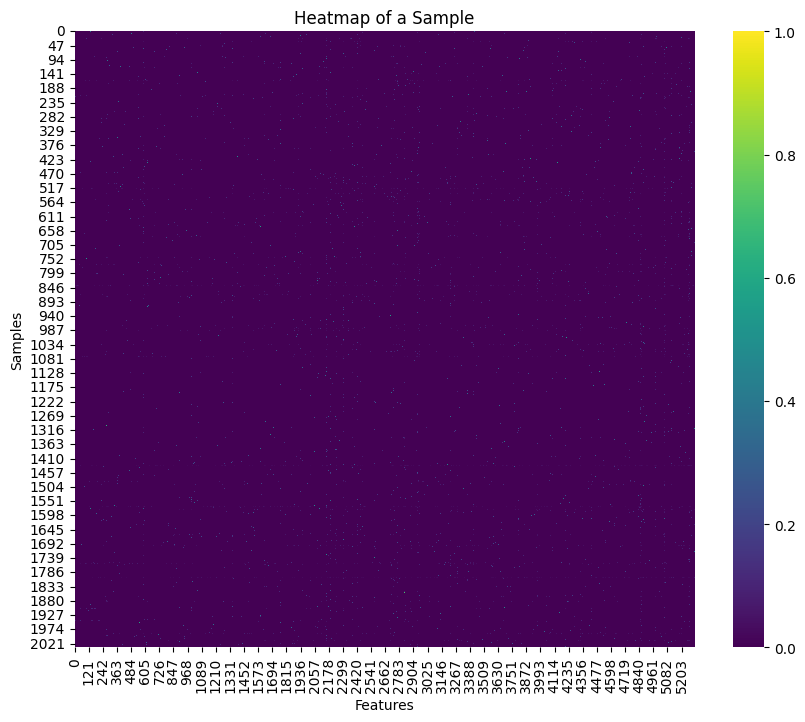

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print(X_train)
print(X_train.todense())

def plot_heatmap(matriz):
  # Create a heatmap of the sample
  plt.figure(figsize=(10, 8))
  sns.heatmap(matriz, cmap='viridis')
  plt.title('Heatmap of a Sample')
  plt.xlabel('Features')
  plt.ylabel('Samples')
  plt.show()

plot_heatmap(X_train.todense())

## TFIDF é normalizada...

In [ ]:
z = X_train.toarray()

z[z != 0], np.min(z), np.max(z)

(array([0.38502646, 0.11288179, 0.10725133, ..., 0.14926035, 0.17346472,
        0.09669961]),
 np.float64(0.0),
 np.float64(1.0))

In [ ]:
import numpy as np

feature_names[np.random.choice(len(feature_names), size=20, replace=False)]

array(['excluding', 'reminds', 'attempting', 'neutron', 'easy',
       'integrated', 'edition', 'fat', 'eternally', 'romans', 'physicist',
       'meter', 'wars', 'grad', 'font', 'protected', 'fonts', 'junk',
       'insane', 'construction'], dtype=object)

# Classificação

In [ ]:
from sklearn.linear_model import RidgeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier

# clf = RidgeClassifier(tol=1e-2, solver="sparse_cg")
clf = LogisticRegression(max_iter=10000)

clf.fit(X_train, y_train)
pred = clf.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred, target_names=target_names))

                    precision    recall  f1-score   support

       alt.atheism       0.66      0.62      0.64       319
     comp.graphics       0.88      0.89      0.88       389
         sci.space       0.74      0.90      0.81       394
talk.religion.misc       0.70      0.50      0.58       251

          accuracy                           0.76      1353
         macro avg       0.75      0.73      0.73      1353
      weighted avg       0.75      0.76      0.75      1353



# Classificação TensorFlow


## Entropia Cruzada

$$
L = - \sum_{i=1}^C y_i \cdot \log(\hat{y}_i)
$$

Em que:

| Símbolo | Significado |
|--------|-------------|
| $C$ | número de classes |
| $y_i$ | valor verdadeiro ($0$ ou $1$ no one-hot) |
| $\hat{y}_i$) | probabilidade prevista para a classe $i$ |

Como apenas uma classe tem valor 1, a expressão reduz-se a:

$$
L = -\log(\hat{y}_k)
$$

Em que $k$ é a classe correta. Isso significa que quanto menor for a probabilidade prevista para a classe correta, **maior a penalização**, e durante o treinamento, o modelo é incentivado a **aumentar a probabilidade da classe correta**.



## Modelo 1, `sparse_categorical_crossentropy`, `y_train=[1,2,3,...]`

In [ ]:
%%time
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# Define the model
model = keras.Sequential([
    # layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)), # old
    keras.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(len(target_names), activation='softmax') # Use the number of categories for the output layer
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(X_train.toarray(), y_train,
                    validation_split=0.2,
                    epochs=10)

# Evaluate the model
y_pred_probs = model.predict(X_test.toarray())
y_pred_numerical = np.argmax(y_pred_probs, axis=1)

# Print predicted numerical labels for debugging
print("Predicted numerical labels:", y_pred_numerical)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_numerical, target_names=target_names))

Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.3673 - loss: 1.3565 - val_accuracy: 0.6609 - val_loss: 1.1122
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7753 - loss: 0.9190 - val_accuracy: 0.7912 - val_loss: 0.6259
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9395 - loss: 0.3953 - val_accuracy: 0.8354 - val_loss: 0.4697
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9620 - loss: 0.1923 - val_accuracy: 0.8305 - val_loss: 0.4241
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9722 - loss: 0.1083 - val_accuracy: 0.8477 - val_loss: 0.4099
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9813 - loss: 0.0600 - val_accuracy: 0.8452 - val_loss: 0.4088
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9730 - loss: 0.0609 - val_accuracy: 0.8378 - val_loss: 0.4145
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9772 - loss: 0.0536 - val_accuracy: 0.8256 - val_loss

In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │       340,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,027,502 (3.92 MB)

 Trainable params: 342,500 (1.31 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 685,002 (2.61 MB)

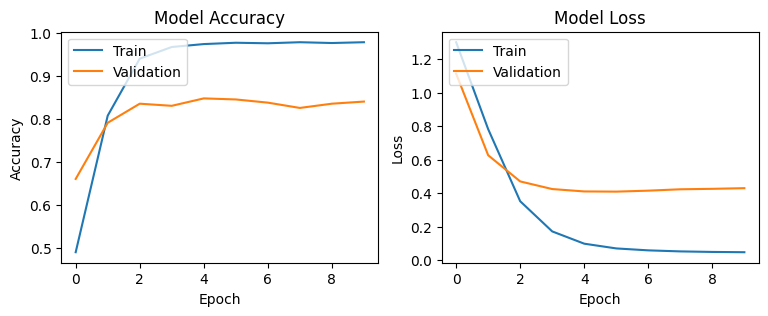

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history):

  # Plot training & validation accuracy values
  plt.figure(figsize=(9,3))
  plt.subplot(1, 2, 1)
  plt.plot(history.history['accuracy'])
  plt.plot(history.history['val_accuracy'])
  plt.title('Model Accuracy')
  plt.ylabel('Accuracy')
  plt.xlabel('Epoch')
  plt.legend(['Train', 'Validation'], loc='upper left')

  # Plot training & validation loss values
  plt.subplot(1, 2, 2)
  plt.plot(history.history['loss'])
  plt.plot(history.history['val_loss'])
  plt.title('Model Loss')
  plt.ylabel('Loss')
  plt.xlabel('Epoch')
  plt.legend(['Train', 'Validation'], loc='upper left')

  plt.show()

plot_history(history)

## Modelo 2, `categorical_crossentropy`, `y_train=[[1,0,0,...],[0,0,1,...],...]`

In [ ]:
%%time
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# Define the model
model = keras.Sequential([
    # layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)), # old
    keras.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(len(target_names), activation='softmax') # Use the number of categories for the output layer
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Convert y_train to numerical labels
y_train_numerical = tf.one_hot(y_train, depth=len(target_names))
y_test_numerical = tf.one_hot(y_test, depth=len(target_names))

# Train the model
history = model.fit(X_train.toarray(), y_train,
                    validation_split=0.2,
                    epochs=10)

# Evaluate the model
y_pred_probs = model.predict(X_test.toarray())
y_pred_numerical = np.argmax(y_pred_probs, axis=1)

# Print predicted numerical labels for debugging
print("Predicted numerical labels:", y_pred_numerical)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_numerical, target_names=target_names))

Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.3762 - loss: 1.3589 - val_accuracy: 0.6192 - val_loss: 1.1336
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7531 - loss: 0.9568 - val_accuracy: 0.8084 - val_loss: 0.6804
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9261 - loss: 0.4366 - val_accuracy: 0.8403 - val_loss: 0.4942
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9629 - loss: 0.1934 - val_accuracy: 0.8305 - val_loss: 0.4318
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9775 - loss: 0.0954 - val_accuracy: 0.8305 - val_loss: 0.4233
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9749 - loss: 0.0741 - val_accuracy: 0.8403 - val_loss: 0.4283
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9806 - loss: 0.0526 - val_accuracy: 0.8354 - val_loss: 0.4350
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9778 - loss: 0.0510 - val_accuracy: 0.8354 - val_lo

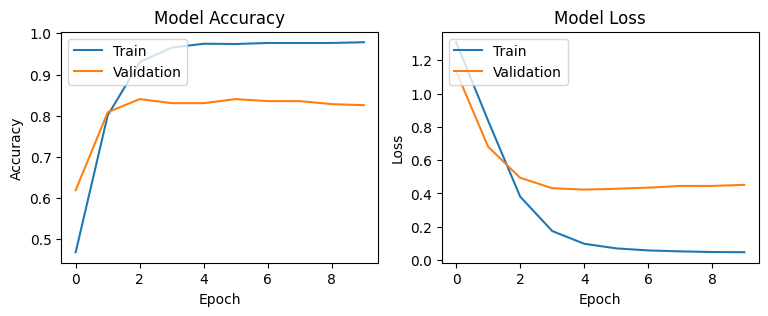

In [ ]:
plot_history(history)